In [4]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Load trained model
model = YOLO(r"E:\sem7\FYP\9_24\objectdetetction\runs\obb11n\obb_run\train_final_fixed4\weights\best.pt")

# Re-evaluate model
metrics = model.val(
    data=r"E:\sem7\FYP\9_24\objectdetetction\runs\obb11n\data.yaml",
    split="val",        # or "test" if you have a test set
    imgsz=640,
    save_json=True,
    save_hybrid=True,
    plots=True
)

# metrics.plots=True automatically regenerates:
# - results.png (loss curves)
# - confusion_matrix.png
# - PR curves per class
# - F1 vs confidence
# - P vs R curves
# - labels_correlogram.png


WARNING 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.3.209  Python-3.10.5 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce GTX 1660 Ti, 6144MiB)
YOLO11n-obb summary (fused): 109 layers, 2,654,503 parameters, 0 gradients, 6.6 GFLOPs



FileNotFoundError: Dataset 'E://sem7/FYP/9_24/objectdetetction/runs/obb11n/data.yaml' images not found, missing path 'E:\sem7\FYP\9_24\objectdetetction\datasets\custom_merged_obb\valid\images'
Note dataset download directory is 'E:\sem7\FYP\9_24\datasets'. You can update this in 'C:\Users\User\AppData\Roaming\Ultralytics\settings.json'

In [5]:
model = YOLO(r"E:\sem7\FYP\9_24\objectdetetction\runs\obb11n\obb_run\train_final_fixed4\weights\best.pt")


In [6]:
metrics = model.val(
    data=r"E:\sem7\FYP\9_24\objectdetetction\runs\obb11n\data.yaml",
    split="val",
    imgsz=640,
    save_json=True,
    save_hybrid=True,
    plots=True
)


WARNING 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.3.209  Python-3.10.5 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce GTX 1660 Ti, 6144MiB)
YOLO11n-obb summary (fused): 109 layers, 2,654,503 parameters, 0 gradients, 6.6 GFLOPs



FileNotFoundError: Dataset 'E://sem7/FYP/9_24/objectdetetction/runs/obb11n/data.yaml' images not found, missing path 'E:\sem7\FYP\9_24\objectdetetction\datasets\custom_merged_obb\valid\images'
Note dataset download directory is 'E:\sem7\FYP\9_24\datasets'. You can update this in 'C:\Users\User\AppData\Roaming\Ultralytics\settings.json'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"E:\sem7\FYP\9_24\objectdetetction\runs\obb11n\obb_run\train_final_fixed4\results.csv")

# Example plots
plt.figure(figsize=(10,6))
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50')
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95')
plt.xlabel('Epoch')
plt.ylabel('mAP')
plt.legend()
plt.grid(True)
plt.title('mAP Evolution')
plt.show()

plt.figure(figsize=(10,6))
plt.plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
plt.plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.title('Precision & Recall Over Epochs')
plt.show()


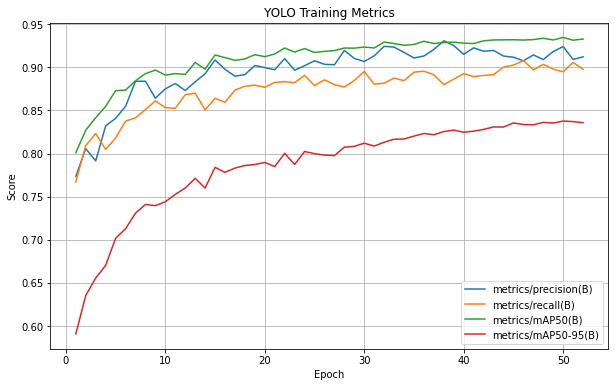

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

path = r"E:\sem7\FYP\9_24\objectdetetction\runs\obb11n\obb_run\train_final_fixed4\results.csv"
df = pd.read_csv(path)

metrics = ["metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]
plt.figure(figsize=(10,6))
for m in metrics:
    plt.plot(df["epoch"], df[m], label=m)
plt.title("YOLO Training Metrics")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

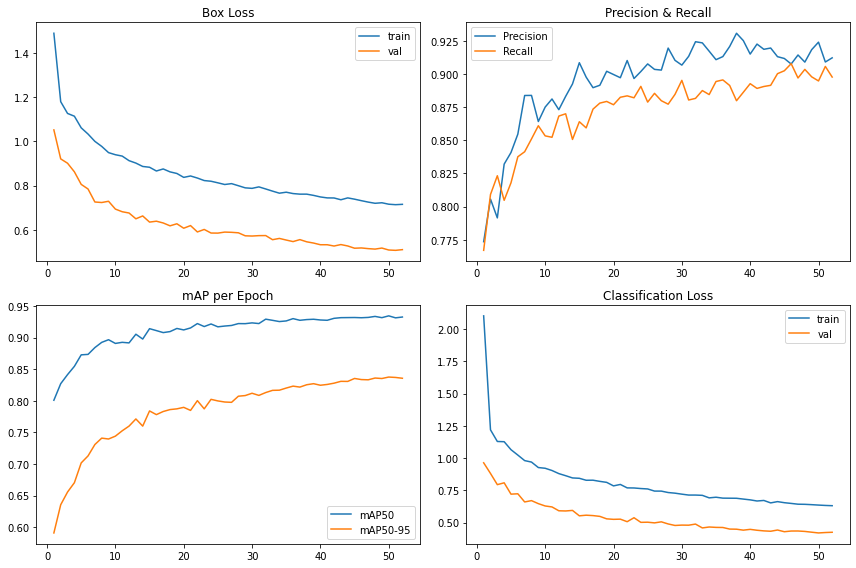

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"E:\sem7\FYP\9_24\objectdetetction\runs\obb11n\obb_run\train_final_fixed4\results.csv")

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(df['epoch'], df['train/box_loss'], label='train')
plt.plot(df['epoch'], df['val/box_loss'], label='val')
plt.title('Box Loss'); plt.legend()

plt.subplot(2, 2, 2)
plt.plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
plt.plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
plt.title('Precision & Recall'); plt.legend()

plt.subplot(2, 2, 3)
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50')
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95')
plt.title('mAP per Epoch'); plt.legend()

plt.subplot(2, 2, 4)
plt.plot(df['epoch'], df['train/cls_loss'], label='train')
plt.plot(df['epoch'], df['val/cls_loss'], label='val')
plt.title('Classification Loss'); plt.legend()

plt.tight_layout()
plt.show()
